<a href="https://colab.research.google.com/github/abhishek18-blog/DataScience-and-ML/blob/main/PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
df = pd.read_csv('/content/survey lung cancer.csv')

# Preprocessing
# Convert categorical 'GENDER' and 'LUNG_CANCER' to numerical
le = LabelEncoder()
df['GENDER'] = le.fit_transform(df['GENDER'])
df['LUNG_CANCER'] = le.fit_transform(df['LUNG_CANCER'])

# Standardizing the features (excluding the target if necessary, but PCA usually looks at all features)
X = df.drop('LUNG_CANCER', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

display(df.head())

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,1,2,2,1,1,2,1,2,2,2,2,2,2,1
1,1,74,2,1,1,1,2,2,2,1,1,1,2,2,2,1
2,0,59,1,1,1,2,1,2,1,2,1,2,2,1,2,0
3,1,63,2,2,2,1,1,1,1,1,2,1,1,2,2,0
4,0,63,1,2,1,1,1,1,1,2,1,2,2,1,1,0


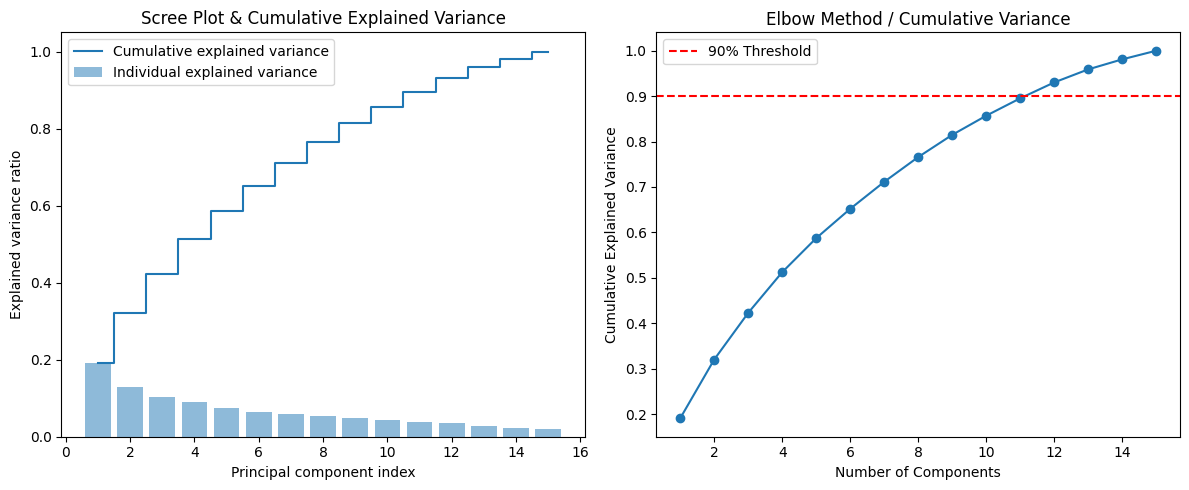

In [2]:
pca = PCA()
pca.fit(X_scaled)

# Calculate variance metrics
exp_var_cumul = np.cumsum(pca.explained_variance_ratio_)

# Plotting Scree Plot and Cumulative Variance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.5, align='center', label='Individual explained variance')
plt.step(range(1, len(exp_var_cumul) + 1), exp_var_cumul, where='mid', label='Cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal component index')
plt.title('Scree Plot & Cumulative Explained Variance')
plt.legend(loc='best')

plt.subplot(1, 2, 2)
plt.plot(range(1, len(exp_var_cumul) + 1), exp_var_cumul, marker='o')
plt.axhline(y=0.90, color='r', linestyle='--', label='90% Threshold')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Elbow Method / Cumulative Variance')
plt.legend()

plt.tight_layout()
plt.show()

In [4]:
# Identify components explaining >90% variance
n_components = np.argmax(exp_var_cumul >= 0.90) + 1
print(f'Optimal number of components to explain 90% variance: {n_components}')

# Re-run PCA with optimal components
pca_opt = PCA(n_components=n_components)
X_pca = pca_opt.fit_transform(X_scaled)

# Create Loadings matrix
loadings = pd.DataFrame(
    pca_opt.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components)],
    index=X.columns
)

# Display the top contributing features for the first few PCs instead of a heatmap
for col in loadings.columns[:5]:
    print(f'\nTop 3 features for {col}:')
    print(loadings[col].abs().sort_values(ascending=False).head(3))

display(loadings)

Optimal number of components to explain 90% variance: 12

Top 3 features for PC1:
ANXIETY              0.403638
YELLOW_FINGERS       0.379757
ALCOHOL CONSUMING    0.333769
Name: PC1, dtype: float64

Top 3 features for PC2:
SHORTNESS OF BREATH    0.445483
FATIGUE                0.430134
ALCOHOL CONSUMING      0.424371
Name: PC2, dtype: float64

Top 3 features for PC3:
COUGHING          0.484381
WHEEZING          0.453469
YELLOW_FINGERS    0.314744
Name: PC3, dtype: float64

Top 3 features for PC4:
SMOKING            0.579186
CHRONIC DISEASE    0.522650
CHEST PAIN         0.278533
Name: PC4, dtype: float64

Top 3 features for PC5:
CHRONIC DISEASE    0.468214
AGE                0.461206
ALLERGY            0.365246
Name: PC5, dtype: float64


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
GENDER,-0.321176,-0.307963,-0.078930,0.261740,-0.170486,-0.088303,-0.050626,-0.302972,-0.212332,-0.193785,0.080893,0.516636
AGE,-0.035186,-0.037483,0.261877,-0.123773,-0.461206,0.576054,0.515775,-0.220544,0.138141,0.045102,-0.127400,-0.018947
SMOKING,0.045253,-0.044374,-0.207534,0.579186,0.201747,0.237192,0.210188,0.386064,0.424805,0.229009,0.096321,0.258972
YELLOW_FINGERS,0.379757,-0.116602,0.314744,0.103913,-0.054111,0.118313,-0.319032,0.117430,-0.344414,0.138846,-0.247741,0.319683
ANXIETY,0.403638,-0.225398,0.136624,0.258252,-0.068688,0.243090,-0.171933,-0.030746,0.003864,-0.327384,-0.012632,0.042750
PEER_PRESSURE,0.305393,-0.079851,0.298827,-0.114713,0.165534,-0.341148,0.505707,0.116732,-0.176502,0.222901,0.320472,0.161218
CHRONIC DISEASE,0.089177,-0.046033,-0.083694,-0.522650,0.468214,0.386325,-0.162024,-0.227588,0.131327,0.187948,0.124095,0.396106
FATIGUE,-0.103716,0.430134,0.299190,0.152077,0.271343,-0.143373,0.312390,-0.196068,-0.057171,-0.338229,-0.152282,0.319528
ALLERGY,-0.252244,-0.217189,0.110067,-0.150089,0.365246,0.272544,0.138164,0.522349,-0.255006,-0.419051,-0.210948,-0.139480
WHEEZING,-0.246324,-0.095105,0.453469,-0.082786,0.039637,-0.247870,-0.215541,0.042508,0.587622,0.064429,-0.382328,0.125026
